# Task 5: Interactive Business Dashboard in Streamlit

## Objective
Develop an interactive dashboard for analyzing sales, profit, and segment-wise performance.

## Dataset Description
Global Superstore Dataset containing 51,290 rows and 24 columns including order details, customer information, product categories, sales, and profit data.

## Conclusion
Cleaned the Global Superstore dataset (dropped Postal Code with 80% missing values) and performed EDA. Built an interactive Streamlit dashboard (app.py) with sidebar filters (Region, Category, Sub-Category) and KPIs — Total Sales, Total Profit, Top 5 Customers by Sales, and Sales by Category charts. EDA revealed Technology as the most profitable category and Tom Ashbrook as the top customer (~$40K sales). The dashboard was successfully deployed and tested via localtunnel.

In [1]:
# importing libraries
import numpy as np                      # for mathematical calculations
import pandas as pd                     # for handling data in tables
import seaborn as sns                   # for creating graphs
import matplotlib.pyplot as plt         # base plotting library

In [3]:
df = pd.read_csv('Global_Superstore2.csv', encoding='latin1')  # loading dataset, latin1 encoding for special characters
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [4]:
print(df.shape)  # rows and columns
print(df.columns.tolist())  # all column names
print(df.isnull().sum())  # missing values check

(51290, 24)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64


In [8]:
# df = df.drop('Postal Code', axis=1)  # dropping postal code - 80% values missing
df['Order Date'] = pd.to_datetime(df['Order Date'])  # converting order date to datetime format
print(df.isnull().sum().sum())  # verifying no missing values left (should be 0)

0


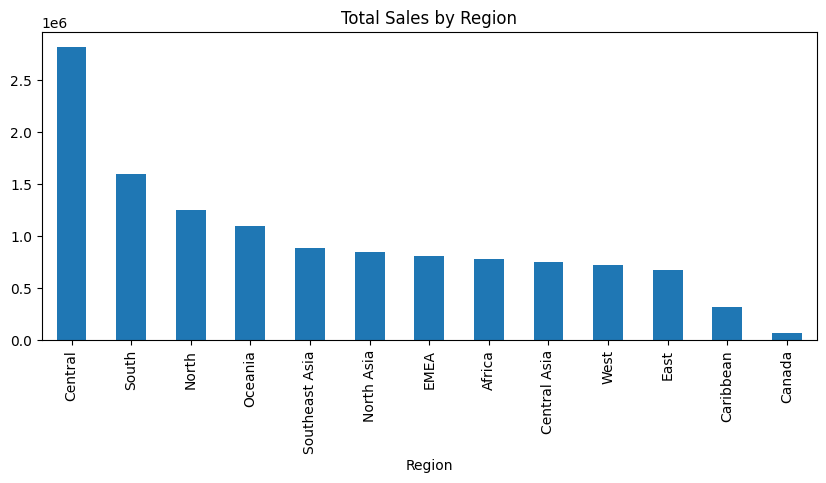

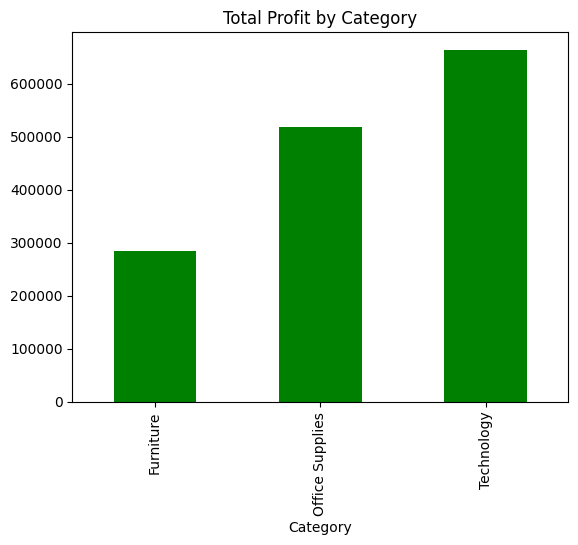

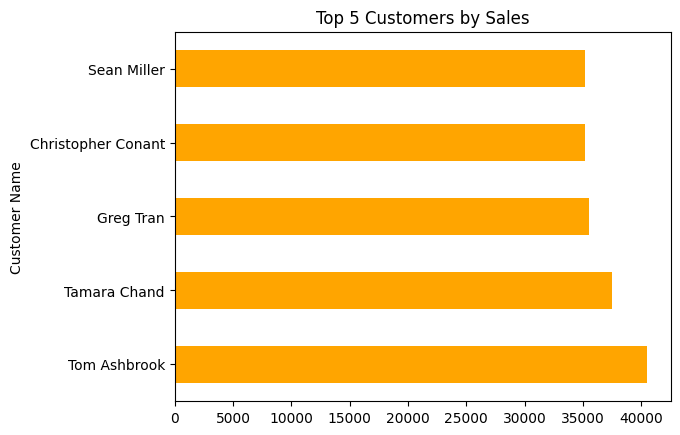

In [9]:
# sales by region
plt.figure(figsize=(10,4))
df.groupby('Region')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')  # total sales per region
plt.title('Total Sales by Region')
plt.show()

# profit by category
df.groupby('Category')['Profit'].sum().plot(kind='bar', color='green')  # total profit per category
plt.title('Total Profit by Category')
plt.show()

# top 5 customers by sales
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5).plot(kind='barh', color='orange')  # top 5 customers
plt.title('Top 5 Customers by Sales')
plt.show()

In [10]:
%%writefile app.py
# Streamlit Business Dashboard - Global Superstore
import streamlit as st  # streamlit for dashboard
import pandas as pd
import matplotlib.pyplot as plt

st.title("Global Superstore Business Dashboard")  # dashboard title

df = pd.read_csv('Global_Superstore2.csv', encoding='latin1')  # loading data

# sidebar filters
region = st.sidebar.multiselect("Select Region", df['Region'].unique())  # region filter
category = st.sidebar.multiselect("Select Category", df['Category'].unique())  # category filter
subcat = st.sidebar.multiselect("Select Sub-Category", df['Sub-Category'].unique())  # sub-category filter

# applying filters
filtered = df.copy()
if region: filtered = filtered[filtered['Region'].isin(region)]
if category: filtered = filtered[filtered['Category'].isin(category)]
if subcat: filtered = filtered[filtered['Sub-Category'].isin(subcat)]

# KPIs
col1, col2 = st.columns(2)  # two columns for KPIs
col1.metric("Total Sales", f"${filtered['Sales'].sum():,.0f}")  # total sales KPI
col2.metric("Total Profit", f"${filtered['Profit'].sum():,.0f}")  # total profit KPI

# top 5 customers chart
st.subheader("Top 5 Customers by Sales")
top5 = filtered.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
st.bar_chart(top5)  # displaying bar chart

# sales by category chart
st.subheader("Sales by Category")
st.bar_chart(filtered.groupby('Category')['Sales'].sum())

Writing app.py


In [11]:
!pip install streamlit -q  # installing streamlit
!npm install -g localtunnel  # installing tunnel to view dashboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 73.1 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 3s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠸

In [ ]:
!streamlit run app.py &>/content/logs.txt &  # running dashboard in background
!npx localtunnel --port 8501  # creating public link

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://tough-tables-pull.loca.lt
